<a href="https://colab.research.google.com/github/JillFang1030/BrainHack_Final_Project/blob/main/0609_Revised_final_project_brainhack_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project

# Plotting


*   For the first part of the project, I want to make an interactive plot using plotly with my project data.
*   TD: typically developed; DD: dyslexia

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import plotly.express as px

# 1. load data
df_dd = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/DD_for_project.xlsx')
df_td = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TD_for_project.xlsx')

# 2. Label
df_dd['Group'] = 'DD'
df_td['Group'] = 'TD'

# 3. Merge
df_project = pd.concat([df_dd, df_td], ignore_index=True)

# 4. Print the names of the columns
print("合併後的欄位有：\n", df_project.columns.tolist())

合併後的欄位有：
 ['ID', 'C_MC', 'C_CTOPP', 'C_RAN', 'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF', 'RF_inc_w/o skip', 'RF_inc_w/ skip', 'Character_recog (raw score)', 'Character_recog (PR)', "IQ_Raven's (raw)", "IQ_Raven's (Standard)", 'fNIRS_Date1', 'Chinese_MAPA', 'Story_Listening', 'Chinese_Priming', 'Chinese_semantic', 'Resting', 'Chinese_RAN', 'fNIRS_Date2', 'Chinese_MAPA.1', 'Story_Listening.1', 'Chinese_Priming.1', 'Chinese_semantic.1', 'Resting.1', 'Chinese_RAN.1', 'Group', 'C_PIC(52)', 'RF_inc_w/o_skip', 'RF_inc_w/_skip', 'Chinese_Semantic']


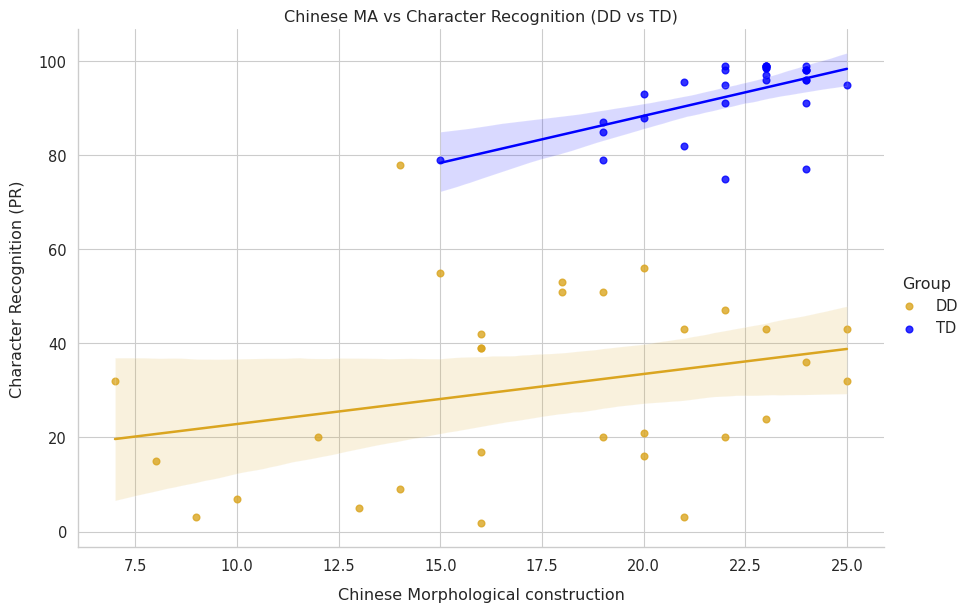

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

sns.lmplot(
    data=df_project,
    x='C_MC',               # X軸：Chinese Morphological construction
    y='Character_recog (PR)',# Y軸：中文字認讀分數
    hue='Group',                    # 顏色：DD vs TD；DD 用金色，TD 用藍色
    palette=['goldenrod', 'blue'],
    height=6,                       # 圖片高度
    aspect=1.5                      # 圖片長寬比
)

plt.xlabel('Chinese Morphological construction', labelpad=10)
plt.ylabel('Character Recognition (PR)', labelpad=10)
plt.savefig('my_research_plot.png', dpi=300, bbox_inches='tight')

plt.title('Chinese MA vs Character Recognition (DD vs TD)')
plt.show()
sns.reset_orig()

In [4]:
import plotly.express as px

# 用 Plotly 畫出 MA 與認字分數的關係，並加上趨勢線
fig = px.scatter(
    df_project,
    x='C_MC',
    y='Character_recog (PR)',
    color='Group',
    trendline="ols",
    hover_data=['ID'],
    labels={'C_MC': 'Chinese MA (C_MC)', 'Character_recog (raw score)': 'Character Recognition (Raw)'},
    title='Interactive Chinese MA vs Character Recognition (DD vs TD)',
    template='plotly_white',
    color_discrete_map={'DD': 'goldenrod', 'TD': 'blue'}
)

fig.show()
fig.write_html("my_interactive_plot.html")

# Brain-Behavior Correlation

Here, I use pre-processed beta value and try to find if there's any brain-behavior correlation.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

folder_path = '/content/drive/MyDrive/Colab Notebooks/'

try:
    df_beta_dd = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_DD.csv')
    df_beta_td = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_TD.csv')
    df_behav_dd = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/DD_for_project.xlsx')
    df_behav_td = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TD_for_project.xlsx')

    print("✅ 所有檔案（CSV 與 Excel）讀取成功")
except Exception as e:
    print(f"❌ 讀取失敗：{e}")
    raise

✅ 所有檔案（CSV 與 Excel）讀取成功


In [7]:
for df in [df_beta_dd, df_beta_td, df_behav_dd, df_behav_td]:
    df.columns = df.columns.str.strip()
beta_all = pd.concat([df_beta_dd, df_beta_td], ignore_index=True)
target_channels = [6, 16, 21]
beta_filtered = beta_all[(beta_all['Channel'].isin(target_channels)) & (beta_all['cond'] == 'MA')]
beta_pivot = beta_filtered.pivot_table(index='Subject', columns='Channel', values='Beta').reset_index()
beta_pivot.columns = ['ID', 'Beta_CH6', 'Beta_CH16', 'Beta_CH21']

In [8]:
behavior_all = pd.concat([df_behav_dd, df_behav_td], ignore_index=True)
behavior_subset = behavior_all[['ID', 'C_MC', 'Character_recog (PR)']].copy()
target_behaviors = [
    'C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'
]

In [9]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import statsmodels.stats.multitest as smm

behavior_all = pd.concat([df_behav_dd, df_behav_td], ignore_index=True)
target_behaviors = [
    'C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'
]
behavior_subset = behavior_all[['ID'] + target_behaviors].copy()
beta_pivot['ID'] = beta_pivot['ID'].astype(int)
behavior_subset['ID'] = behavior_subset['ID'].astype(int)
final_df = pd.merge(beta_pivot, behavior_subset, on='ID', how='inner')

def run_correlation_with_fdr(df, channels, behaviors):
    results = []
    raw_p_values = [] # 用來存取所有的原始 p 值

    # 計算 3 個 Channel × 9 個指標 = 27 次 Pearson 相關
    for ch in channels:
        for bh in behaviors:
            if ch in df.columns and bh in df.columns:
                valid_data = df[[ch, bh]].dropna()
                if len(valid_data) > 2:
                    r_val, p_val = pearsonr(valid_data[ch], valid_data[bh])
                else:
                    r_val, p_val = np.nan, np.nan
            else:
                r_val, p_val = np.nan, np.nan

            results.append({
                'Channel': ch,
                'Behavior': bh,
                'Pearson_r': round(r_val, 3) if not np.isnan(r_val) else np.nan,
                'p_value_raw': round(p_val, 4) if not np.isnan(p_val) else np.nan
            })
            # 將 p 值存入清單
            raw_p_values.append(1.0 if np.isnan(p_val) else p_val)

    # 27 次比較的 FDR 校正
    reject, p_corrected, _, _ = smm.multipletests(raw_p_values, alpha=0.05, method='fdr_bh')

    # 將校正結果存回表格
    for idx, res in enumerate(results):
        res['p_value_FDR_corrected'] = round(p_corrected[idx], 4)
        res['Significant_After_FDR'] = '★ TRUE' if reject[idx] else ''
        p_raw = res['p_value_raw']
        res['Significant_Raw'] = '*' if (p_raw is not None and p_raw < 0.05) else ''

    return pd.DataFrame(results)


# 執行分析：計算整體的 27 行總表

target_channels_short = ['Beta_CH6', 'Beta_CH16', 'Beta_CH21']

# 全體的相關分析
print("========== 全體兒童（N=30）27次相關分析結果 ==========")
analysis_results_all = run_correlation_with_fdr(final_df, target_channels_short, target_behaviors)
print(analysis_results_all.to_string(index=False))
analysis_results_all.to_excel('All_subjects_3ch_9behav_results.xlsx', index=False)

print("\n" + "="*80 + "\n")

========== 全體兒童（N=30）27次相關分析結果 ==========
  Channel             Behavior  Pearson_r  p_value_raw  p_value_FDR_corrected Significant_After_FDR Significant_Raw
 Beta_CH6                 C_MC      0.045       0.7345                 0.9711                                      
 Beta_CH6 Character_recog (PR)     -0.116       0.3764                 0.9711                                      
 Beta_CH6              C_CTOPP      0.017       0.8991                 0.9711                                      
 Beta_CH6                C_RAN     -0.004       0.9782                 0.9782                                      
 Beta_CH6                 C_CR     -0.108       0.4124                 0.9711                                      
 Beta_CH6                 C_WR     -0.040       0.7625                 0.9711                                      
 Beta_CH6                C_PIC     -0.085       0.5163                 0.9711                                      
 Beta_CH6           C_PIC (52)

In [10]:
# 將全體兒童的 27 行相關分析結果存成 Excel 檔案
excel_filename = 'All_Subjects_60_Correlation_Results.xlsx'

analysis_results_all.to_excel(excel_filename, index=False)

print("\n" + "="*60)
print(f"🎉 全體兒童 Excel 表格已成功導出！")
print(f"📁 檔案名稱：{excel_filename}")
print("說明：點開 Colab 左側的資料夾，就能下載囉！")
print("="*60)


🎉 全體兒童 Excel 表格已成功導出！
📁 檔案名稱：All_Subjects_60_Correlation_Results.xlsx
說明：點開 Colab 左側的資料夾，就能下載囉！


只有CH16的C_PIC (52)有超級微小的顯著

## Doing a whole brain check

正在建立 8x4 散佈圖矩陣 (對應 Character_recog (PR))...
🎉 Image saved: whole_brain_32_channels_scatter_plots.png


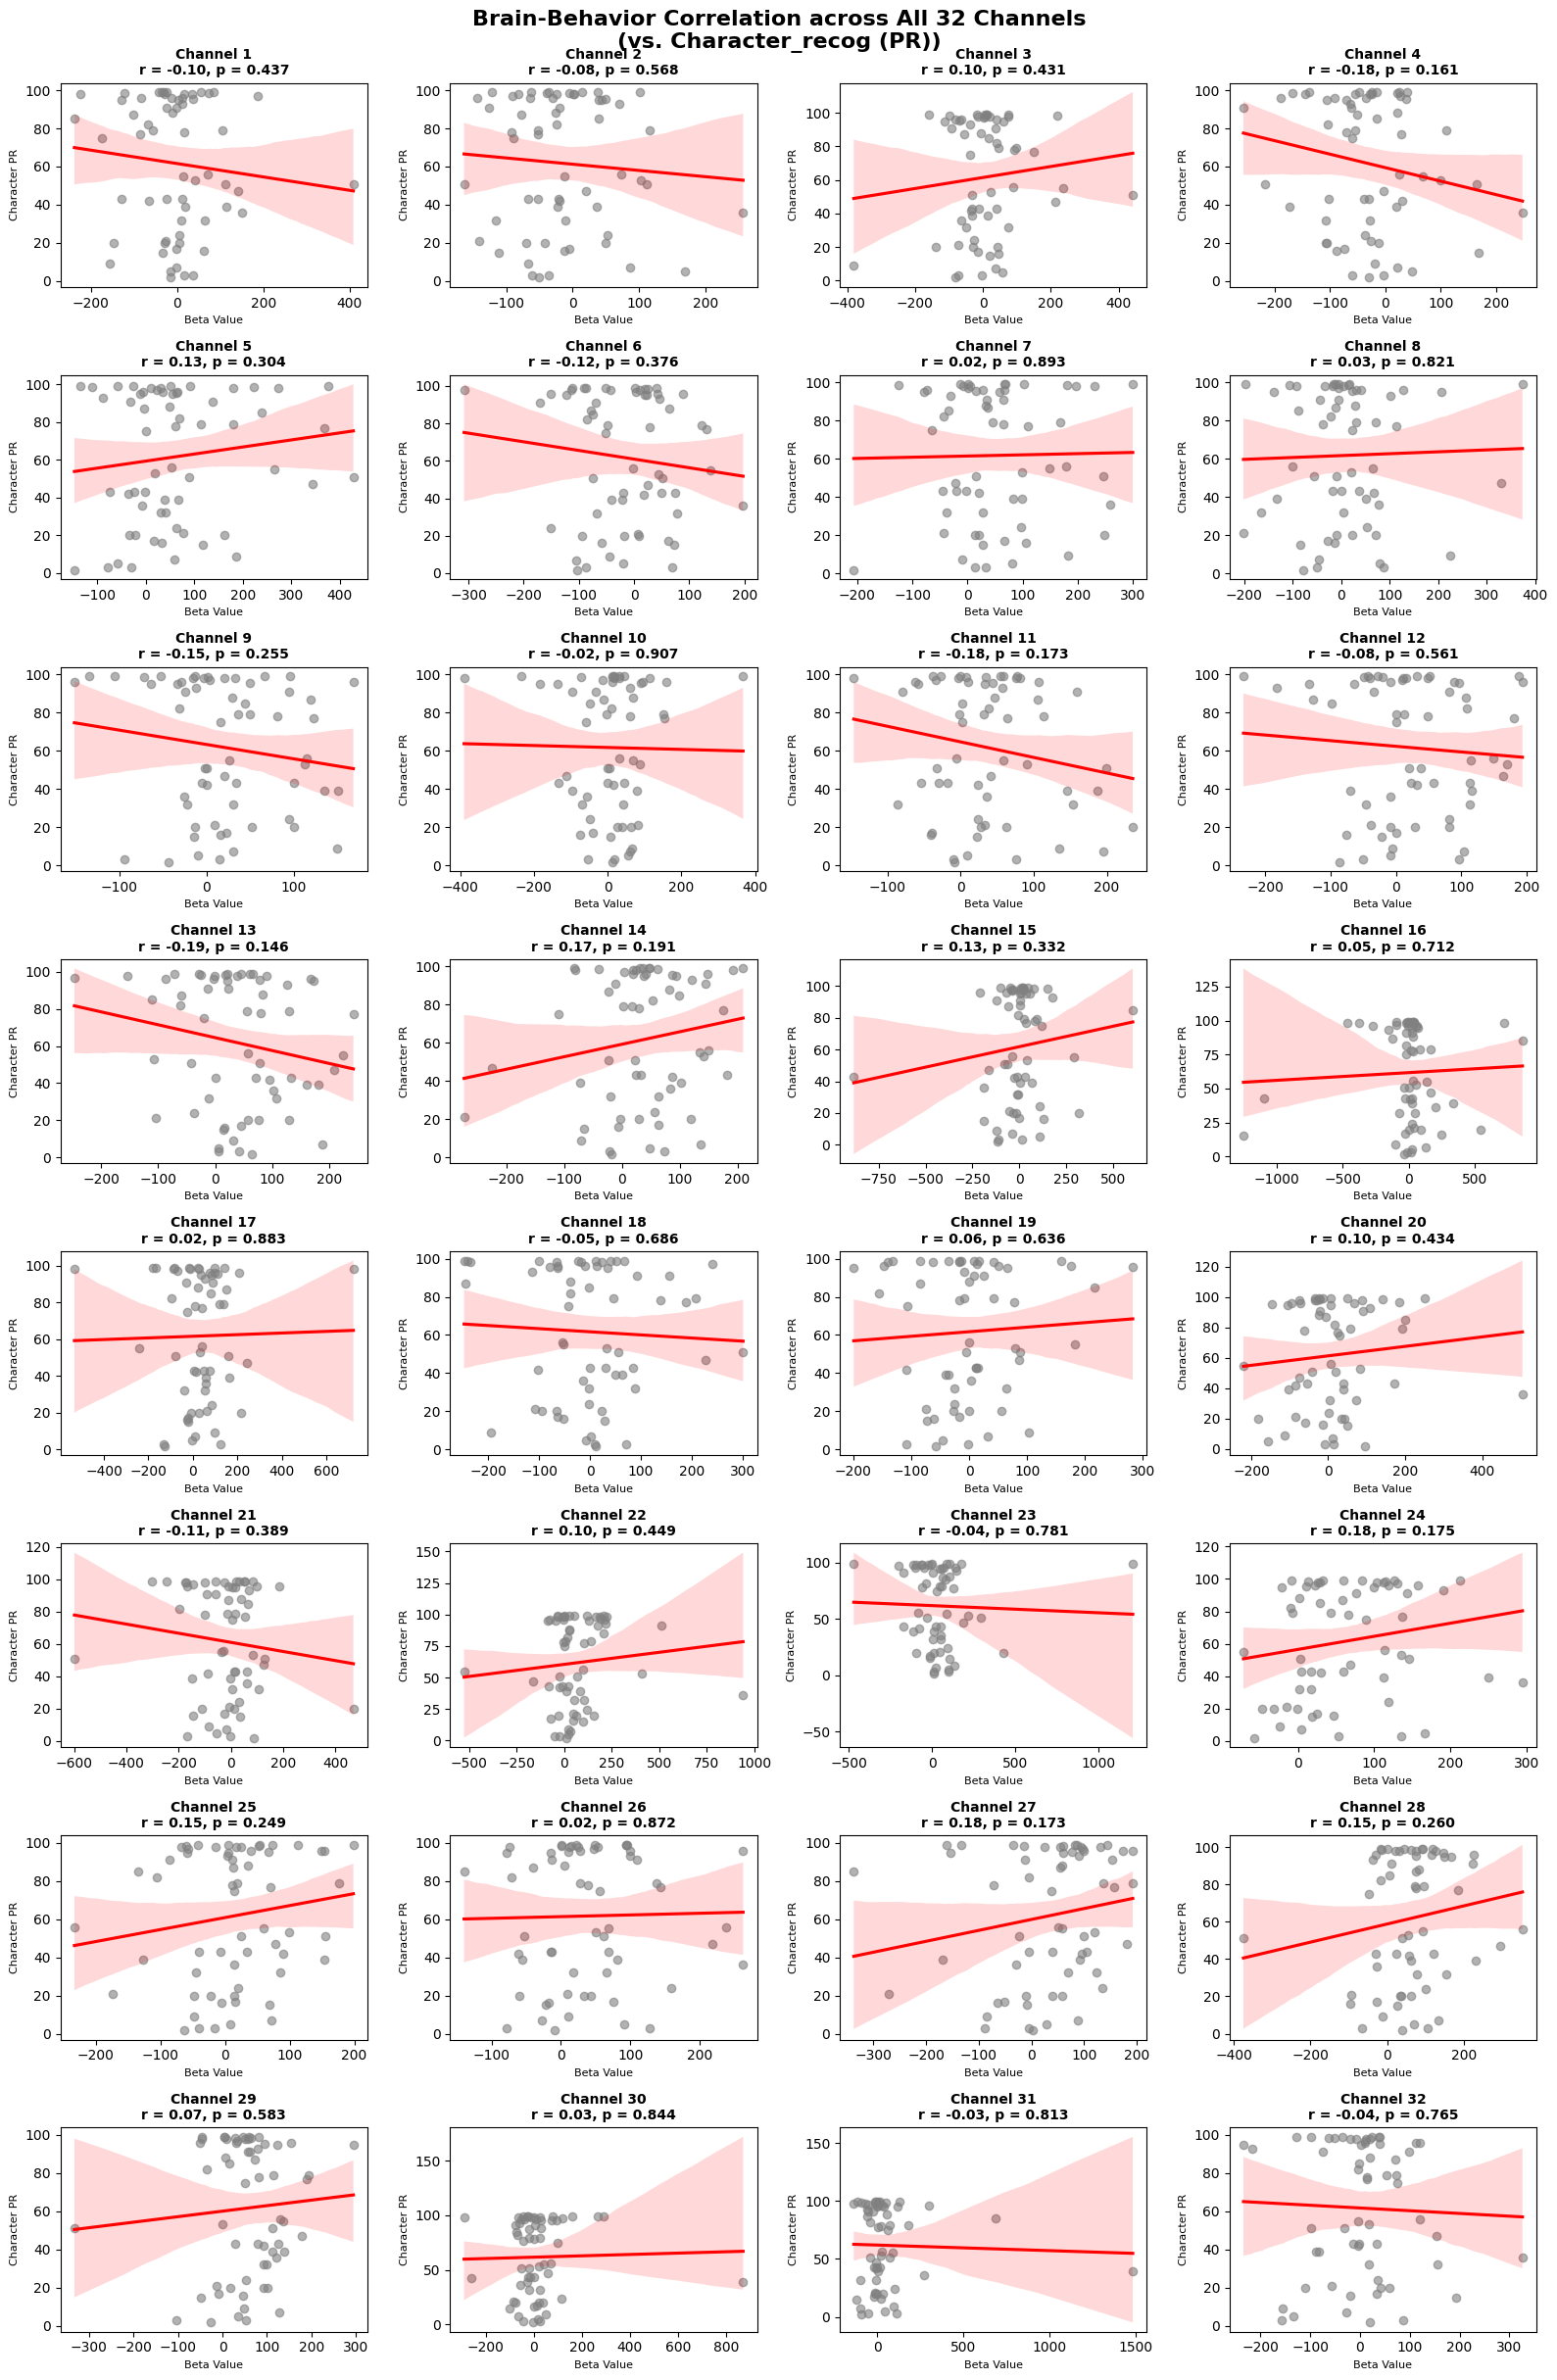


=== 全腦 32 Channel FDR 校正總表 (vs. 識字量 PR) ===
 Channel  Pearson_r  p_value_raw  p_value_FDR_corrected  Significant_After_FDR
       1  -0.102178     0.437243               0.844600                  False
       2  -0.075185     0.568043               0.907145                  False
       3   0.103563     0.431025               0.844600                  False
       4  -0.183235     0.161103               0.844600                  False
       5   0.134809     0.304439               0.844600                  False
       6  -0.116264     0.376354               0.844600                  False
       7   0.017681     0.893336               0.907145                  False
       8   0.029804     0.821157               0.907145                  False
       9  -0.149366     0.254681               0.844600                  False
      10  -0.015381     0.907145               0.907145                  False
      11  -0.178308     0.172863               0.844600                  False
      1

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import statsmodels.stats.multitest as smm
import seaborn as sns
import matplotlib.pyplot as plt

beta_ma_all = beta_all[beta_all['cond'] == 'MA'].copy()
beta_pivot_32 = beta_ma_all.pivot_table(index='Subject', columns='Channel', values='Beta').reset_index()
beta_pivot_32.rename(columns={'Subject': 'ID'}, inplace=True)
beta_pivot_32['ID'] = beta_pivot_32['ID'].astype(int)
behavior_subset_32 = behavior_all[['ID', 'C_MC', 'Character_recog (PR)']].copy()
behavior_subset_32['ID'] = behavior_subset_32['ID'].astype(int)
final_df_32 = pd.merge(beta_pivot_32, behavior_subset_32, on='ID', how='inner')
channels = sorted([ch for ch in beta_pivot_32.columns if ch != 'ID'])

# 建立 8 × 4 的 matplotlib subplots
fig, axes = plt.subplots(8, 4, figsize=(16, 24), sharex=False, sharey=False)
axes = axes.flatten()

p_values_character = []
r_values_character = []

print("正在建立 8x4 散佈圖矩陣 (對應 Character_recog (PR))...")

# Plotting with loop
for i, ch in enumerate(channels):
    # 清除缺失值
    valid_data = final_df_32[['ID', ch, 'Character_recog (PR)']].dropna()

    x = valid_data[ch].values
    y = valid_data['Character_recog (PR)'].values

    # Pearson Correlation
    if len(x) > 2:
        r, p = pearsonr(x, y)
    else:
        r, p = np.nan, np.nan

    r_values_character.append(r)
    p_values_character.append(p)

    # 畫散佈圖與紅色趨勢線
    sns.regplot(x=x, y=y, ax=axes[i],
                scatter_kws={'alpha':0.6, 'color':'gray'},
                line_kws={'color':'red'})

    # 設定每格小標題：顯示 Channel 數字、r值與原始 p值
    axes[i].set_title(f'Channel {ch}\nr = {r:.2f}, p = {p:.3f}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Beta Value', fontsize=8)
    axes[i].set_ylabel('Character PR', fontsize=8)

# 調整畫布排版
plt.tight_layout()
plt.suptitle('Brain-Behavior Correlation across All 32 Channels\n(vs. Character_recog (PR))',
             y=1.01, fontsize=16, fontweight='bold')

# 新增存檔指令：把 32 張大圖存成高解析度的 PNG 圖檔
plt.savefig('whole_brain_32_channels_scatter_plots.png', dpi=300, bbox_inches='tight')
print("🎉 Image saved: whole_brain_32_channels_scatter_plots.png")

plt.show()
# 統計校正：對 32 個 p 值進行 FDR 校正
p_values_clean = [0.999 if np.isnan(v) else v for v in p_values_character]
reject, p_corrected, _, _ = smm.multipletests(p_values_clean, alpha=0.05, method='fdr_bh')

# 製作表格
results_df = pd.DataFrame({
    'Channel': channels,
    'Pearson_r': r_values_character,
    'p_value_raw': p_values_character,
    'p_value_FDR_corrected': p_corrected,
    'Significant_After_FDR': reject
})

print("\n" + "="*50)
print("=== 全腦 32 Channel FDR 校正總表 (vs. 識字量 PR) ===")
print("="*50)
print(results_df.to_string(index=False))

sig_channels = results_df[results_df['Significant_After_FDR'] == True]['Channel'].tolist()
if len(sig_channels) > 0:
    print(f"\n🎉 Great! After FDR correction, the significant channels are: {sig_channels}")
else:
    print(f"\nOops! After FDR correction, no channels survived. See scatter plot.")

# 把 FDR 校正總表存成 Excel 檔
results_df.to_excel('whole_brain_fdr_correction_results.xlsx', index=False)
print("🎉 【表格已自動存檔】：whole_brain_fdr_correction_results.xlsx")

print("\n=== 全腦 32 Channel FDR 校正總表 ===")
print(results_df.to_string(index=False))

## Back to focus on the 3 channels.

✅ 檔案重讀成功！大資料庫就位。
⏳ 正在計算目標 3通道 ✕ 9指標 的 27 次相關矩陣...
🎉 【目標 3 通道熱圖已成功存檔】：target_3ch_9behav_heatmap.png


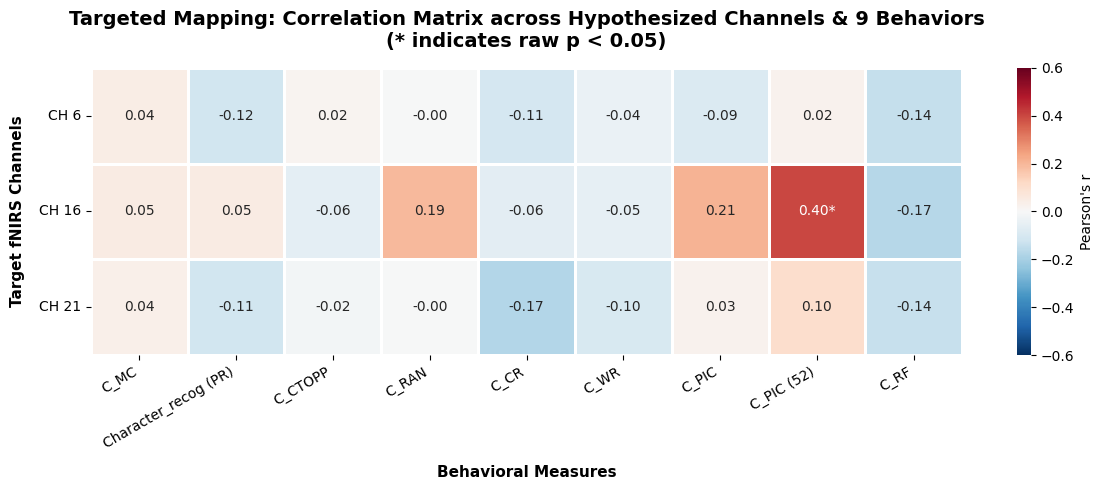

🎉 【27行原始統計總表已自動存檔】：All_Subjects_60_Correlation_Results.xlsx


In [12]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt


# 1. 讀取檔案與建立大資料庫
try:
    df_beta_dd = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_DD.csv')
    df_beta_td = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_TD.csv')
    df_behav_dd = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/DD_for_project.xlsx')
    df_behav_td = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TD_for_project.xlsx')

    for df in [df_beta_dd, df_beta_td, df_behav_dd, df_behav_td]:
        df.columns = df.columns.str.strip()

    beta_all = pd.concat([df_beta_dd, df_beta_td], ignore_index=True)
    behavior_all = pd.concat([df_behav_dd, df_behav_td], ignore_index=True)
    print("✅ 檔案重讀成功！大資料庫就位。")
except Exception as e:
    print(f"❌ 檔案讀取失敗，請確認雲端硬碟路徑：{e}")
    raise


# 鎖定3 個 Channel (CH6, CH16, CH21)
target_channels = [6, 16, 21]

beta_ma_all = beta_all[beta_all['cond'] == 'MA'].copy()
beta_pivot_3ch = beta_ma_all.pivot_table(index='Subject', columns='Channel', values='Beta').reset_index()
beta_pivot_3ch.rename(columns={'Subject': 'ID'}, inplace=True)
beta_pivot_3ch['ID'] = beta_pivot_3ch['ID'].astype(int)

# 9 個行為指標名單
target_behaviors = [
    'C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'
]
behavior_subset = behavior_all[['ID'] + target_behaviors].copy()
behavior_subset['ID'] = behavior_subset['ID'].astype(int)

# 合併成3通道的大表
final_df_3ch = pd.merge(beta_pivot_3ch, behavior_subset, on='ID', how='inner')

# 計算 3 通道 ✕ 9 指標 = 27 次相關

print("⏳ 正在計算目標 3通道 ✕ 9指標 的 27 次相關矩陣...")
matrix_r = pd.DataFrame(index=[f'CH {ch}' for ch in target_channels], columns=target_behaviors)
matrix_annot = pd.DataFrame(index=[f'CH {ch}' for ch in target_channels], columns=target_behaviors)
results_list_27 = []

for ch in target_channels:
    for bh in target_behaviors:
        if ch in final_df_3ch.columns and bh in final_df_3ch.columns:
            valid_data = final_df_3ch[[ch, bh]].dropna()
            if len(valid_data) > 2:
                r_val, p_val = pearsonr(valid_data[ch], valid_data[bh])
            else:
                r_val, p_val = np.nan, np.nan
        else:
            r_val, p_val = np.nan, np.nan

        matrix_r.loc[f'CH {ch}', bh] = r_val if not np.isnan(r_val) else 0.0

        # 如果原始 p 值 < 0.05，標註星號
        if not np.isnan(p_val) and p_val < 0.05:
            matrix_annot.loc[f'CH {ch}', bh] = f"{r_val:.2f}*"
        else:
            matrix_annot.loc[f'CH {ch}', bh] = f"{r_val:.2f}" # 沒顯著也顯示 r 值，讓圖表資訊更豐富

        results_list_27.append({
            'Channel': f'CH {ch}',
            'Behavior': bh,
            'Pearson_r': round(r_val, 3) if not np.isnan(r_val) else np.nan,
            'p_value_raw': round(p_val, 4) if not np.isnan(p_val) else np.nan
        })


# 繪製3✕9 heatmap
plt.figure(figsize=(12, 5))
matrix_r = matrix_r.astype(float)

sns.heatmap(matrix_r,
            annot=matrix_annot.values,
            fmt="",
            cmap='RdBu_r',
            vmin=-0.6, vmax=0.6,
            center=0.0,
            linewidths=1.0,
            cbar_kws={'label': "Pearson's r"})

plt.title('Targeted Mapping: Correlation Matrix across Hypothesized Channels & 9 Behaviors\n(* indicates raw p < 0.05)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Behavioral Measures', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Target fNIRS Channels', fontsize=11, fontweight='bold', labelpad=10)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

# 存新檔
plt.savefig('target_3ch_9behav_heatmap.png', dpi=300, bbox_inches='tight')
print("🎉 【目標 3 通道熱圖已成功存檔】：target_3ch_9behav_heatmap.png")

plt.show()

# 儲存 27 行總表成 Excel
df_results_27 = pd.DataFrame(results_list_27)
df_results_27.to_excel('All_Subjects_60_Correlation_Results.xlsx', index=False)
print("🎉 【27行原始統計總表已自動存檔】：All_Subjects_60_Correlation_Results.xlsx")

Since there's no clear pattern overall, I separate the two groups and try to see the correlation.

In [22]:
# 分別看 DD 組和 TD 組的相關性
# 1. 找出 DD 組和 TD 組各自的 ID 列表
dd_ids = df_behav_dd['ID'].unique()
td_ids = df_behav_td['ID'].unique()

# 2. 從最終合併的大表 (final_df) 中把兩組人拆開
df_dd_only = final_df[final_df['ID'].isin(dd_ids)]
df_td_only = final_df[final_df['ID'].isin(td_ids)]

# 3. 分別執行分析
print("========== DD (閱讀障礙組) 相關分析 ==========")
results_dd = run_correlation_with_fdr(df_dd_only,
                             ['Beta_CH6', 'Beta_CH16', 'Beta_CH21'],
                             ['C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'])
print(results_dd)

print("\n========== TD (典型發展組) 相關分析 ==========")
results_td = run_correlation_with_fdr(df_td_only,
                             ['Beta_CH6', 'Beta_CH16', 'Beta_CH21'],
                             ['C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'])
print(results_td)

========== DD (閱讀障礙組) 相關分析 ==========
      Channel              Behavior  Pearson_r  p_value_raw  \
0    Beta_CH6                  C_MC      0.346       0.0608   
1    Beta_CH6  Character_recog (PR)      0.366       0.0466   
2    Beta_CH6               C_CTOPP      0.200       0.2902   
3    Beta_CH6                 C_RAN     -0.017       0.9270   
4    Beta_CH6                  C_CR      0.225       0.2324   
5    Beta_CH6                  C_WR      0.239       0.2034   
6    Beta_CH6                 C_PIC      0.171       0.3661   
7    Beta_CH6            C_PIC (52)      0.025       0.8969   
8    Beta_CH6                  C_RF      0.066       0.7425   
9   Beta_CH16                  C_MC      0.125       0.5119   
10  Beta_CH16  Character_recog (PR)      0.037       0.8453   
11  Beta_CH16               C_CTOPP     -0.074       0.6980   
12  Beta_CH16                 C_RAN     -0.089       0.6383   
13  Beta_CH16                  C_CR     -0.015       0.9383   
14  Beta_CH16    

In [19]:
# 檢查 DD 組每個欄位的標準差（如果標準差是 0，就是原因一！）
print("=== DD 組各欄位的標準差 ===")
print(df_dd_only[channels_cols + behaviors].std())

print("\n=== TD 組各欄位的標準差 ===")
print(df_td_only[channels_cols + behaviors].std())

=== DD 組各欄位的標準差 ===
Beta_CH6                 77.220762
Beta_CH16               341.443370
Beta_CH21               161.574188
C_MC                      5.000690
Character_recog (PR)     19.477130
C_CTOPP                   6.855152
C_RAN                     5.395122
C_CR                     26.532912
C_WR                     15.279917
C_PIC                     3.782750
C_PIC (52)                4.866493
C_RF                     10.044488
dtype: float64

=== TD 組各欄位的標準差 ===
Beta_CH6                 93.452128
Beta_CH16               249.393331
Beta_CH21               112.553187
C_MC                      2.150915
Character_recog (PR)      7.561050
C_CTOPP                   2.525502
C_RAN                     7.926048
C_CR                     26.497473
C_WR                      8.900536
C_PIC                     3.264050
C_PIC (52)                     NaN
C_RF                     16.804111
dtype: float64


🎉 【分組對比熱圖已成功存檔】：subgroup_dd_td_3ch_heatmap.png


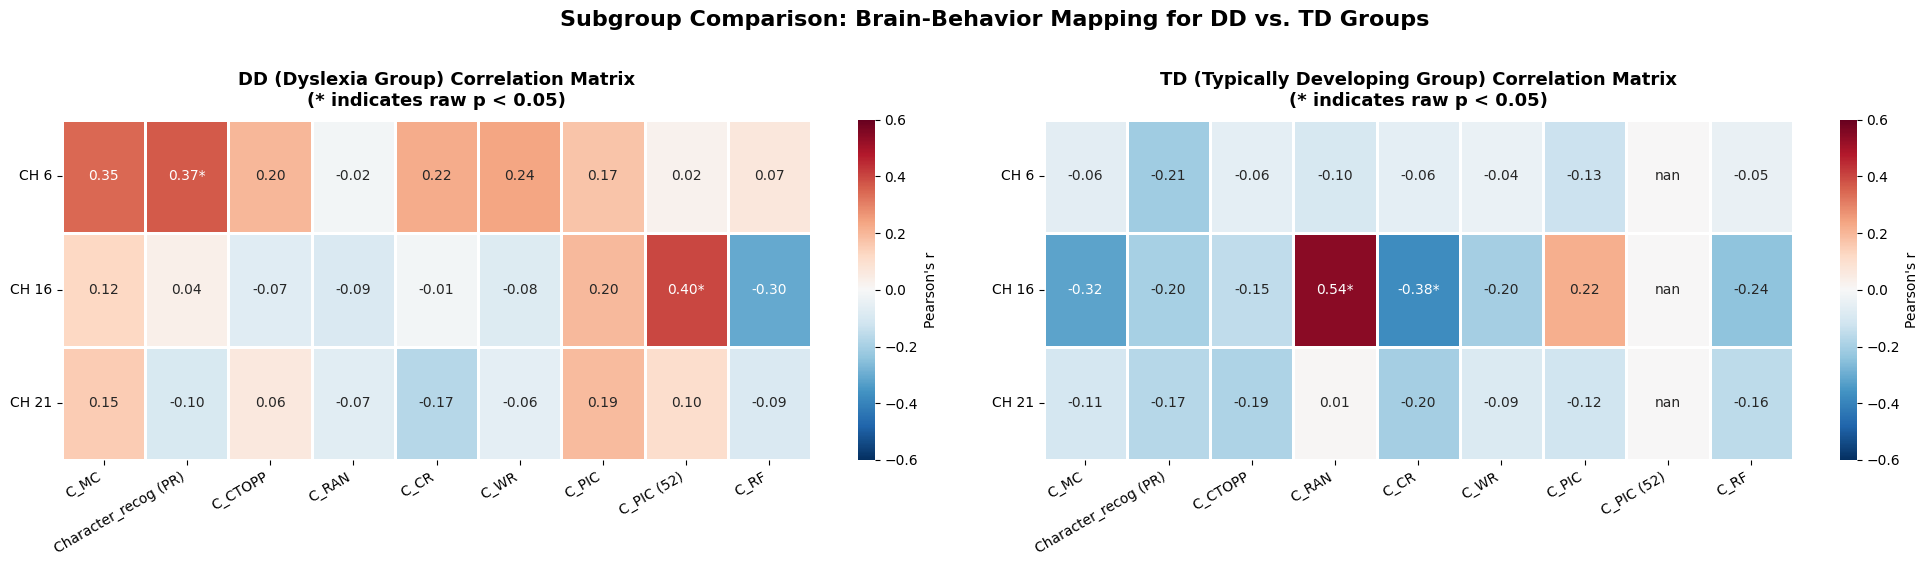

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 對齊欄位名稱
channels_cols = ['Beta_CH6', 'Beta_CH16', 'Beta_CH21']
channels_labels = ['CH 6', 'CH 16', 'CH 21']
behaviors = ['C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN', 'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF']

def build_matrix_data(df, ch_cols, bh_list):
    mat_r = pd.DataFrame(index=channels_labels, columns=bh_list, dtype=float)
    mat_annot = pd.DataFrame(index=channels_labels, columns=bh_list, dtype=str)

    for ch_col, ch_lab in zip(ch_cols, channels_labels):
        for bh in bh_list:
            if ch_col in df.columns and bh in df.columns:
                valid_data = df[[ch_col, bh]].dropna()
                if len(valid_data) > 2:
                    r_val, p_val = pearsonr(valid_data[ch_col], valid_data[bh])
                else:
                    r_val, p_val = np.nan, np.nan
            else:
                r_val, p_val = np.nan, np.nan

            mat_r.loc[ch_lab, bh] = r_val if not np.isnan(r_val) else 0.0

            if not np.isnan(p_val) and p_val < 0.05:
                mat_annot.loc[ch_lab, bh] = f"{r_val:.2f}*"
            else:
                mat_annot.loc[ch_lab, bh] = f"{r_val:.2f}"

    return mat_r, mat_annot

# 1. 計算兩組的矩陣
dd_r, dd_annot = build_matrix_data(df_dd_only, channels_cols, behaviors)
td_r, td_annot = build_matrix_data(df_td_only, channels_cols, behaviors)

# 2. 畫並排雙熱圖
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5.5))

# 左圖：DD 組
sns.heatmap(dd_r,
            annot=dd_annot.values,
            fmt="",
            cmap='RdBu_r',
            vmin=-0.6, vmax=0.6,
            center=0.0,
            linewidths=1.0,
            cbar_kws={'label': "Pearson's r"},
            ax=ax1)
ax1.set_title('DD (Dyslexia Group) Correlation Matrix\n(* indicates raw p < 0.05)', fontsize=13, fontweight='bold', pad=10)
ax1.set_xticklabels(behaviors, rotation=30, ha='right')
ax1.set_yticklabels(channels_labels, rotation=0)

# 右圖：TD 組
sns.heatmap(td_r,
            annot=td_annot.values,
            fmt="",
            cmap='RdBu_r',
            vmin=-0.6, vmax=0.6,
            center=0.0,
            linewidths=1.0,
            cbar_kws={'label': "Pearson's r"},
            ax=ax2)
ax2.set_title('TD (Typically Developing Group) Correlation Matrix\n(* indicates raw p < 0.05)', fontsize=13, fontweight='bold', pad=10)
ax2.set_xticklabels(behaviors, rotation=30, ha='right')
ax2.set_yticklabels(channels_labels, rotation=0)

# Title
plt.suptitle('Subgroup Comparison: Brain-Behavior Mapping for DD vs. TD Groups', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()

# 💾 儲存高解析度並排對比圖
plt.savefig('subgroup_dd_td_3ch_heatmap.png', dpi=300, bbox_inches='tight')
print("🎉 【分組對比熱圖已成功存檔】：subgroup_dd_td_3ch_heatmap.png")

plt.show()